In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
class KNN_MANUAL:
    def __init__(self, k):
        self.k = k
    
    def fit(self, x, y):
        self.x_train = np.array(x)
        self.y_train = np.array(y)
        
    def predict(self, inputs):
        y_pred = []
        for i in inputs:
            distances = []
            
            for j in self.x_train:
                distances.append(np.linalg.norm(i - j))
            
            indices = np.argsort(distances)[:self.k]
            
            label_counts = {}
            for idx in indices:
                label = self.y_train[idx]
                label_counts[label] = label_counts.get(label, 0) + 1
            
            most_common_label = max(label_counts, key=label_counts.get)
            y_pred.append(most_common_label)
                
        return np.array(y_pred)


In [30]:
class KNN:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
    
    def predict(self, X_test):
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)
    
    def _predict(self, x):
        # Compute Euclidean distances
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
        # Get the k nearest samples
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [2]:
df = pd.read_csv('telescope_data.csv')

In [3]:
df.shape
df.head()


,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [4]:
df = df.drop(df.columns[0],axis = 1)

In [5]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [6]:
df = df.drop(df[df['class'] == 'g'].sample(n=5644).index)


In [7]:
df['class'].value_counts()

class
g    6688
h    6688
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
x_test,x_val,y_test,y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

## Scalling the data

In [9]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

## Getting the best K

```
Trying K from 1 to 15 to get the best k (with the highest accuracy on the validation data set)
```

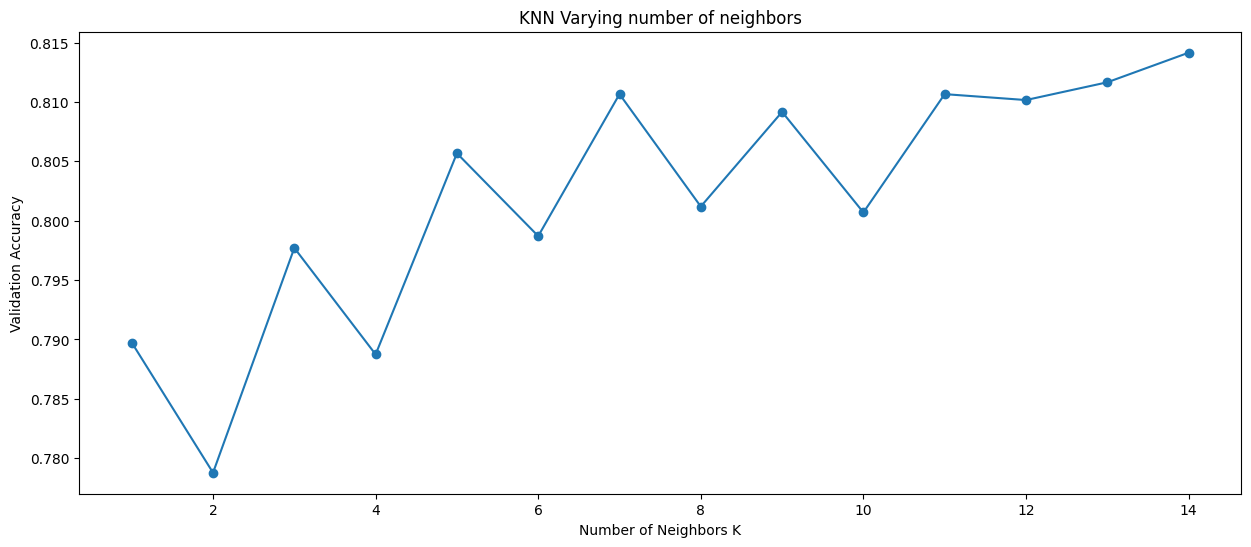

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


accuracy = []
accuracy_man = []
for i in range (1 , 15) :
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    
    
    
    y_pred = knn.predict(x_val)
    

    accuracy.append(accuracy_score(y_val, y_pred))
    
plt.figure(figsize=(15,6))
plt.plot(range(1,15), accuracy, marker='o')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Validation Accuracy')
plt.title('KNN Varying number of neighbors')
plt.show()

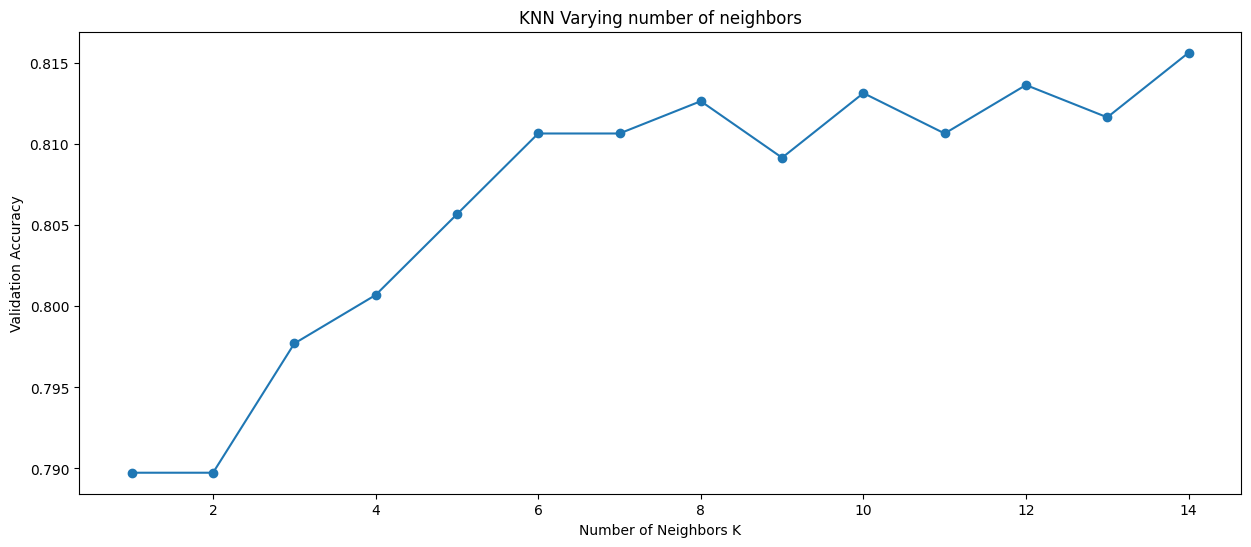

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


accuracy = []
for i in range (1 , 15) :
    knn = KNN_MANUAL(i)
    knn.fit(x_train, y_train)
    
    
    
    y_pred = knn.predict(x_val)
    

    accuracy.append(accuracy_score(y_val, y_pred))
    
plt.figure(figsize=(15,6))
plt.plot(range(1,15), accuracy, marker='o')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Validation Accuracy')
plt.title('KNN Varying number of neighbors')
plt.show()

```
The best k is 7 as it has the highest accuracy hence the lowest loss but need to check with the test data set to know if the model is overfitting or not
```

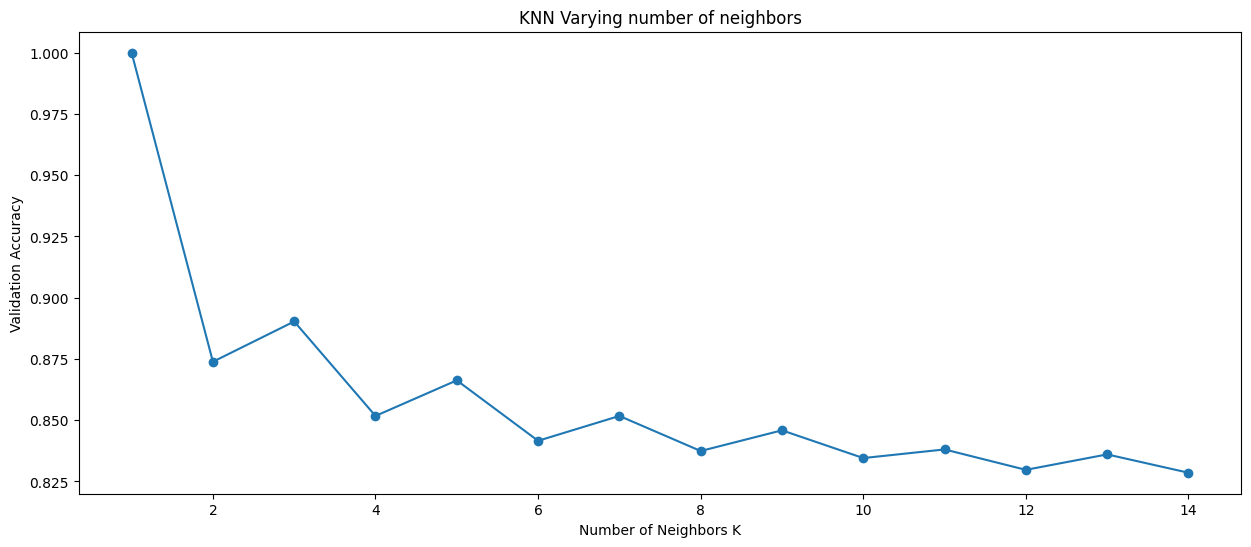

In [12]:

accuracy_train = []
for i in range (1 , 15) :
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)

    accuracy_train.append(accuracy_score(y_train ,knn.predict(x_train)))
    
plt.figure(figsize=(15,6))
plt.plot(range(1,15), accuracy_train, marker='o')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Validation Accuracy')
plt.title('KNN Varying number of neighbors')
plt.show()    

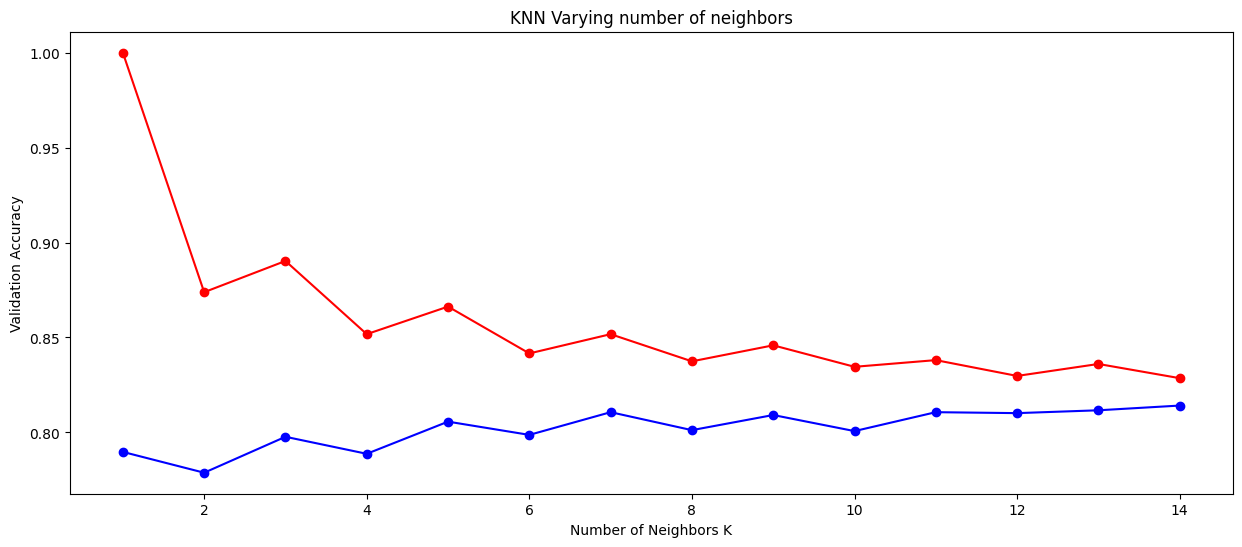

In [13]:
plt.figure(figsize=(15,6))
plt.plot(range(1,15), accuracy_train, marker='o',color = 'r')
plt.plot(range(1,15), accuracy, marker='o',color='b')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Validation Accuracy')
plt.title('KNN Varying number of neighbors')
plt.show() 

## UNDERFITTING VS OVERFITTING


```
Overfitting happens when k is too high (like 15) as the model is too complex to capture the complexity of the data
```

```
Underfitting happens when k is too low (like 1) as the model is too simple and captures noise in the data
```

```
So we choose 7 as it has high validation accuracy as well as high training accuracy
```